# Conditional Gaussian Baseline

Closed-form PCA-space SC->FC baseline using the conditional mean of a joint Gaussian.

This notebook focuses on:
- fit/eval of the analytical model
- covariance and correlation structure in latent space
- componentwise conditional uncertainty
- optional direct covariate conditioning by concatenating standardized covariates to the SC latent input


In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import main
import models.config
import models.conditional_gaussian

importlib.reload(models.conditional_gaussian)
importlib.reload(models.config)
importlib.reload(main)

from main import Sim

In [2]:
all_cov_sources = ["age", "sex", "race_eth", "fs_volumes", "fs_all"]

sim = Sim(
    model_name="CrossModal_ConditionalGaussian",
    config_overrides={
        "model": {
            "cov_sources": all_cov_sources}
    },
    parcellation="Glasser",
    source="SC",
    target="FC",
    shuffle_seed=0,
    batch_size=128,
)


/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


CrossModal_ConditionalGaussian init | domain=pca | src=SC tgt=FC | k=512 | cov_estimator=ledoit_wolf | lambda_ridge=0.001 | zscore_pca_scores=False | use_covariates=True cov_dim=1 | cond(Sigma_11+lamI)=4.484e+01 | shrinkage=0.1888
Number of unique demographic categories: 14
Top-1 accuracy: 0.041  (8 of 195 subjects had rank 1) (chance=0.005)
Average rank percentile: 0.738 (chance=0.5)


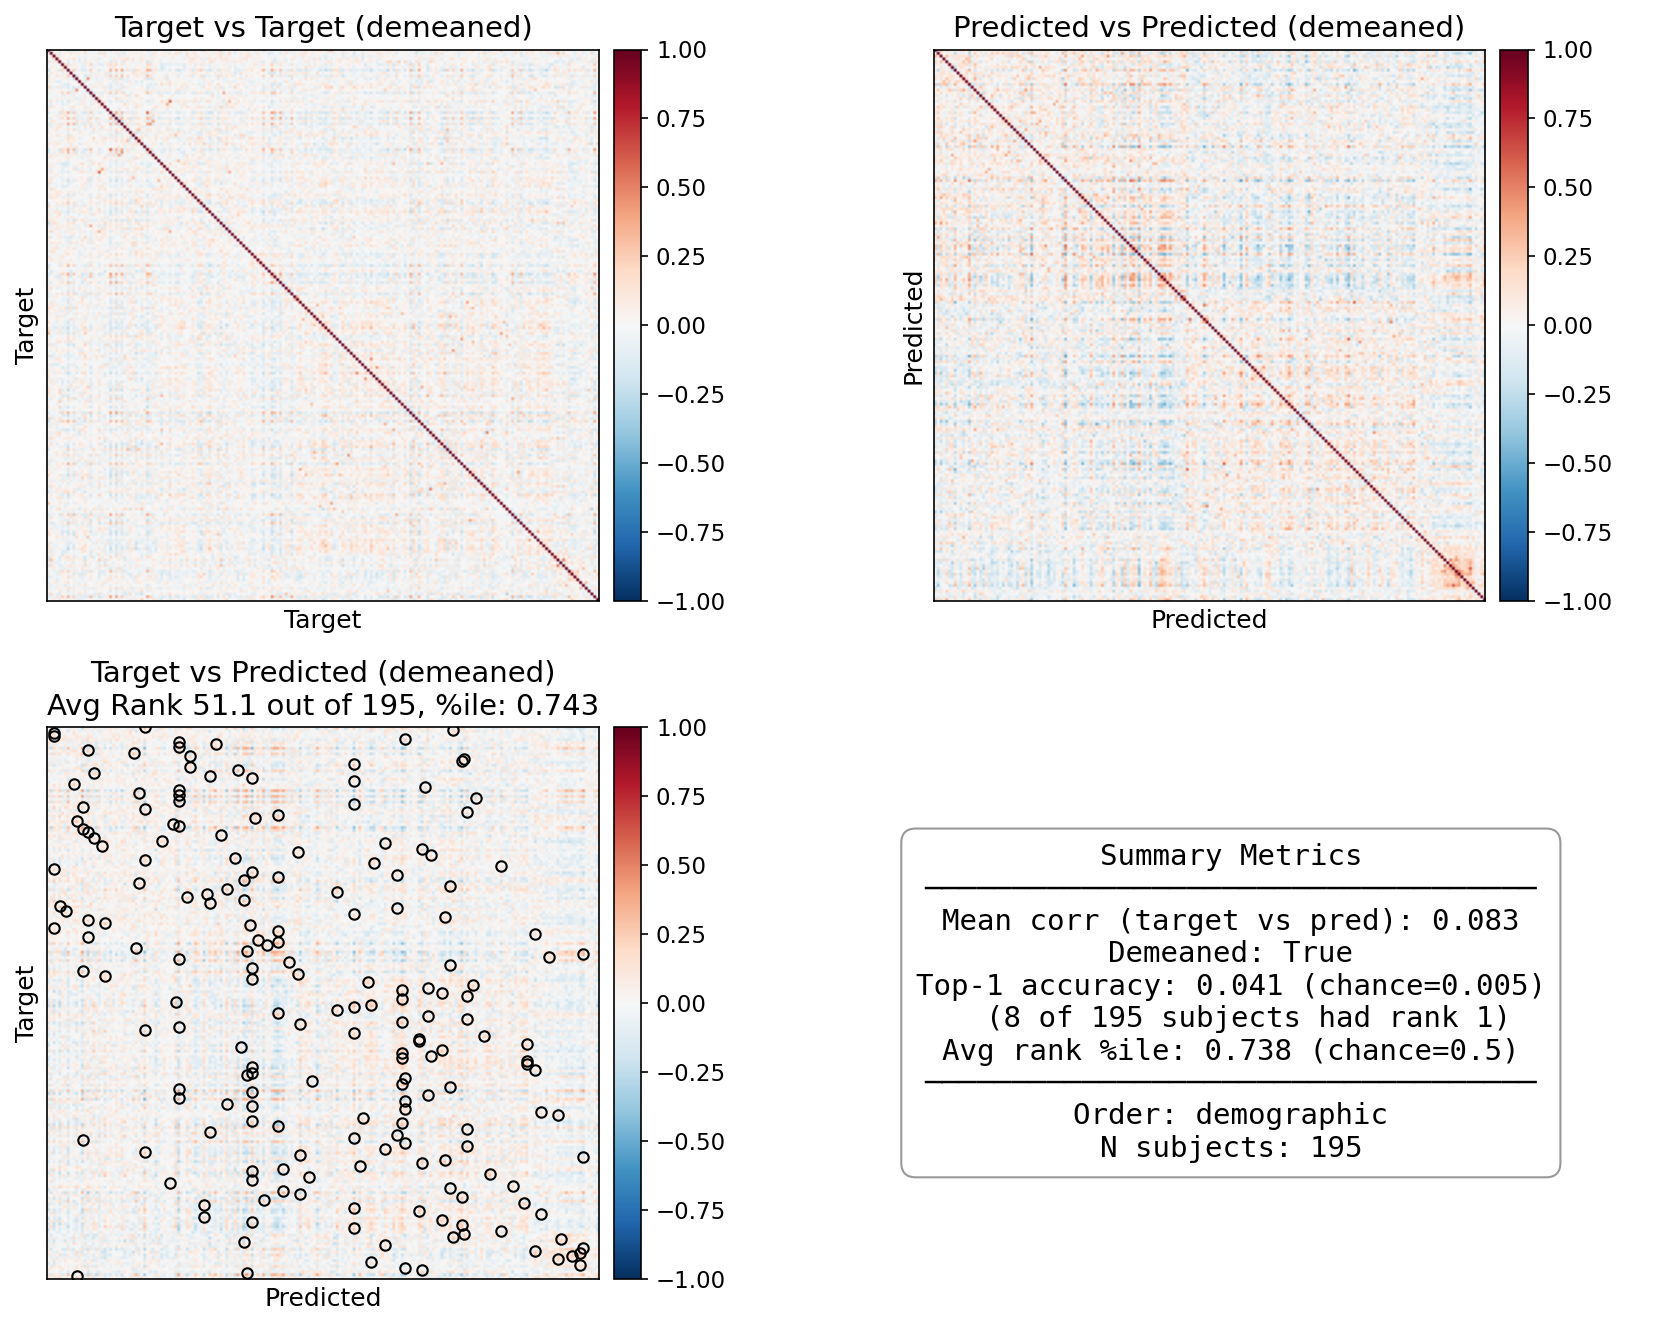

returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.09947311
   0.36341408]]


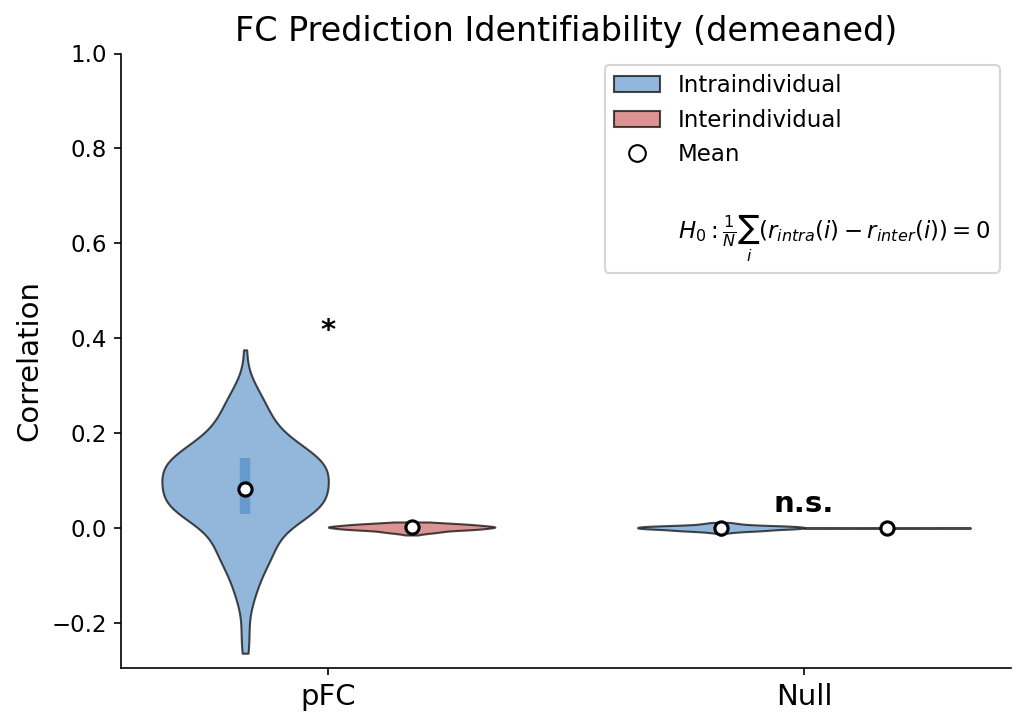


Identifiability Summary:
Condition    r_intra    r_inter    d          t          p            Cohen d   
----------------------------------------------------------------------
pFC          0.0829     0.0011     0.0818     10.63      4.45e-21     0.76      
Null         0.0004     -0.0001    0.0005     1.35       1.78e-01     0.10      


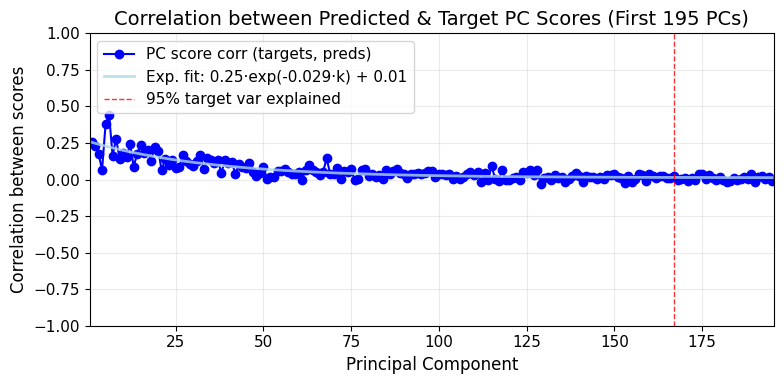

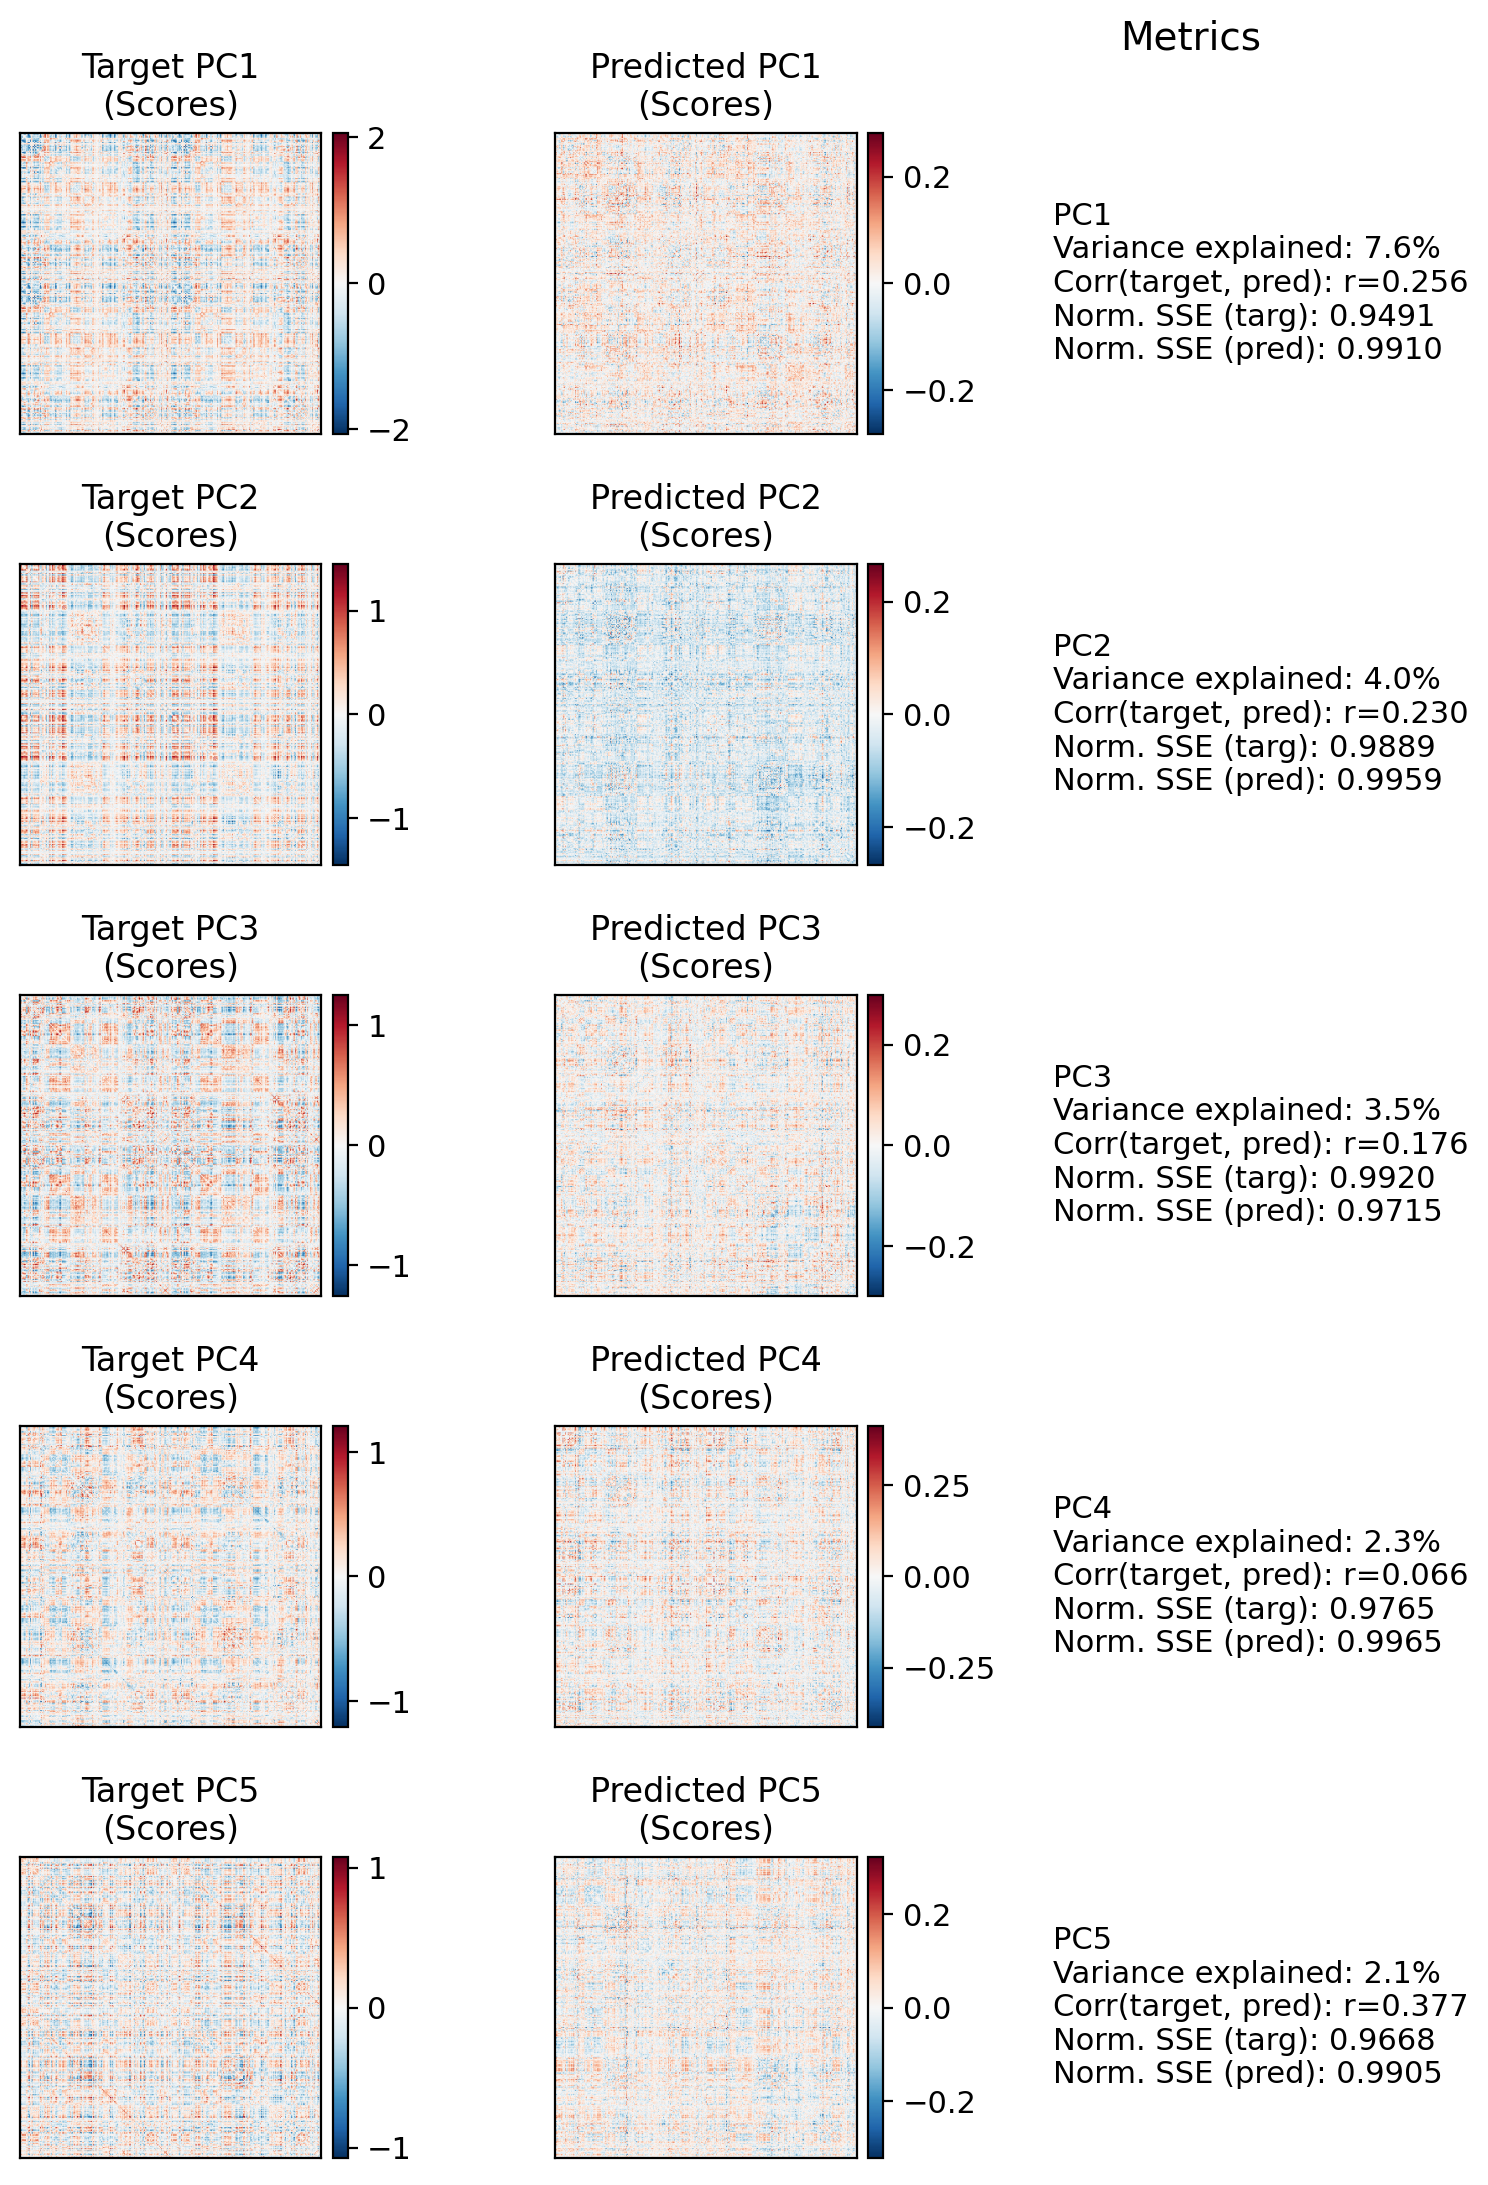

{'mse': np.float32(0.014720575),
 'r2': np.float32(-0.12298017),
 'pearson': np.float32(0.82164085),
 'demeaned_pearson': np.float64(0.08287419800135136),
 'avg_rank': np.float64(0.7350427350427351),
 'top1_acc': np.float64(0.046153846153846156)}

In [18]:
config_override = {
    "model": {
        "n_components_pca": 512,
        "lambda_ridge": 1e-3,
        "covariance_estimator": "ledoit_wolf",  # empirical, ledoit_wolf, oas
        "zscore_pca_scores": False,
        "use_covariates": True,
        "cov_sources": ["age"],
    }
}

run_out = sim.run_single(
    mode="dev",
    save_checkpoint=False,
    config_override=config_override,
    run_eval=True,
)

run_out["test_metrics"]["base_metrics"]


In [12]:
model = run_out["model"]
diag = model.get_diagnostics()

summary = {
    "n_components_pca": model.n_components_pca,
    "lambda_ridge": model.lambda_ridge,
    "covariance_estimator": model.covariance_estimator,
    "zscore_pca_scores": model.zscore_pca_scores,
    "use_covariates": diag["use_covariates"],
    "cov_sources": diag["cov_sources"],
    "covariate_dim": diag["covariate_dim"],
    "condition_number": diag["condition_number"],
    "shrinkage_value": diag["shrinkage_value"],
}
summary


{'n_components_pca': 512,
 'lambda_ridge': 0.001,
 'covariance_estimator': 'ledoit_wolf',
 'zscore_pca_scores': False,
 'use_covariates': True,
 'cov_sources': ['fs_all'],
 'covariate_dim': 199,
 'condition_number': 318.0677348098088,
 'shrinkage_value': 0.15949249644346622}

In [13]:
def _to_np(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def plot_heatmap(ax, arr, title, cmap="coolwarm", center=None):
    arr = _to_np(arr)
    im = ax.imshow(arr, aspect="auto", interpolation="nearest", cmap=cmap) if center is None else ax.imshow(arr, aspect="auto", interpolation="nearest", cmap=cmap, vmin=-np.max(np.abs(arr)), vmax=np.max(np.abs(arr)))
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def corr_from_cov(cov):
    cov = _to_np(cov)
    std = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
    corr = cov / np.outer(std, std)
    corr[~np.isfinite(corr)] = 0.0
    np.fill_diagonal(corr, 1.0)
    return corr

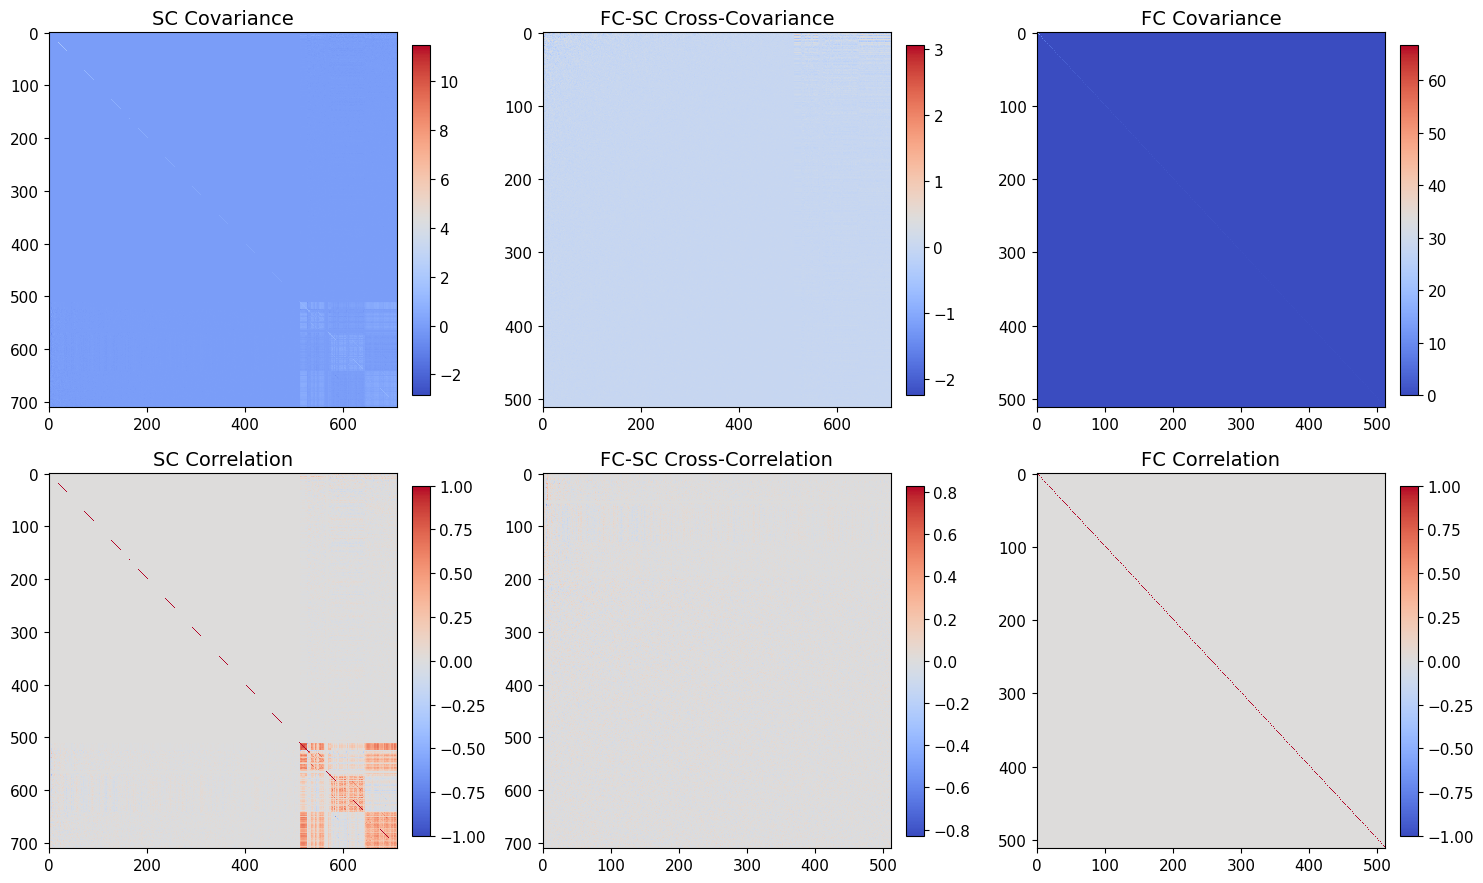

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plot_heatmap(axes[0, 0], diag["Sigma_11"], "SC Covariance")
plot_heatmap(axes[0, 1], diag["Sigma_21"], "FC-SC Cross-Covariance")
plot_heatmap(axes[0, 2], diag["Sigma_22"], "FC Covariance")
plot_heatmap(axes[1, 0], diag["source_correlation"], "SC Correlation", center=0.0)
plot_heatmap(axes[1, 1], diag["cross_correlation"], "FC-SC Cross-Correlation", center=0.0)
plot_heatmap(axes[1, 2], diag["target_correlation"], "FC Correlation", center=0.0)
plt.tight_layout()
plt.show()

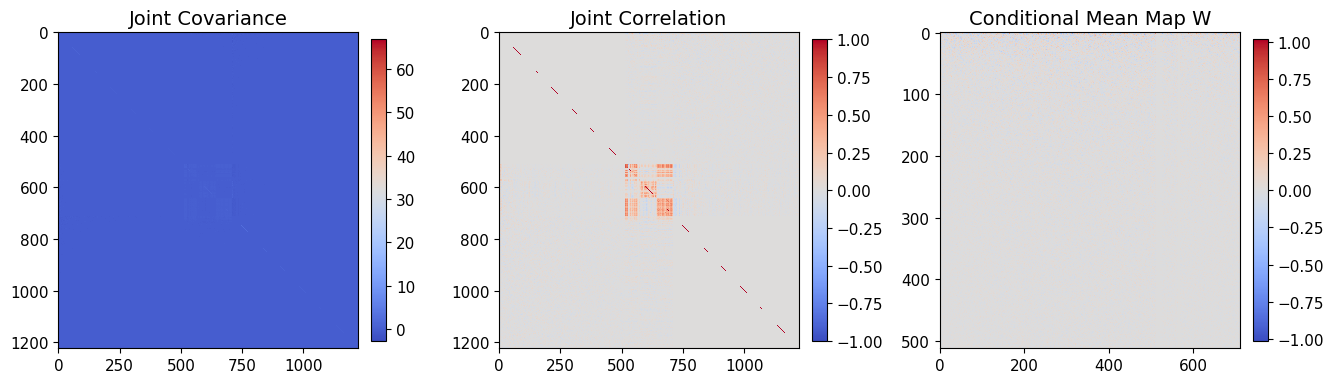

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
plot_heatmap(axes[0], diag["Sigma_joint"], "Joint Covariance")
plot_heatmap(axes[1], diag["joint_correlation"], "Joint Correlation", center=0.0)
plot_heatmap(axes[2], diag["W"], "Conditional Mean Map W", center=0.0)
plt.tight_layout()
plt.show()

In [16]:
# Remaining FC latent uncertainty after conditioning on SC:
# the remaining standard deviation of each FC latent component
# after conditioning on the observed SC latent components
# sqrt(diag(Sigma_fc|sc))
conditional_std = _to_np(diag["conditional_std"])

# Unconditional / marginal FC latent variability before conditioning on SC:
# sqrt(diag(Sigma_22))
target_marginal_std = np.sqrt(np.clip(np.diag(_to_np(diag["Sigma_22"])), 0.0, None))

# Fraction of uncertainty left after observing SC.
# ~1.0 means SC explains very little for that component.
# Smaller values mean SC constrains that FC component more strongly.
uncertainty_ratio = conditional_std / np.clip(target_marginal_std, 1e-8, None)

# Fraction of variance explained by conditioning on SC:
# 1 - Var(FC | SC) / Var(FC)
# Larger values mean that FC component is more predictable from SC.
explained_fraction = 1.0 - (conditional_std ** 2) / np.clip(target_marginal_std ** 2, 1e-8, None)

# Componentwise uncertainty summary:
# sorting by conditional_std highlights the FC latent components that remain
# most uncertain even after observing SC.
uncertainty_df = pd.DataFrame({
    "component": np.arange(len(conditional_std)),
    "conditional_std": conditional_std,
    "target_marginal_std": target_marginal_std,
    "uncertainty_ratio": uncertainty_ratio,
    "explained_fraction": explained_fraction,
}).sort_values("conditional_std", ascending=False)

uncertainty_df.head(15)


,component,conditional_std,target_marginal_std,uncertainty_ratio,explained_fraction
0,0,5.053289,8.173593,0.618246,0.617772
1,1,3.338709,5.221364,0.639432,0.591126
2,2,2.995731,4.635143,0.646308,0.582286
3,3,2.438055,3.913141,0.623043,0.611818
4,4,2.218364,3.453962,0.642267,0.587494
5,5,1.940093,3.117811,0.622261,0.612791
9,9,1.785673,2.763430,0.646180,0.582451
6,6,1.754630,2.992955,0.586253,0.656307
7,7,1.739969,2.838459,0.612998,0.624234
8,8,1.717537,2.801601,0.613056,0.624163


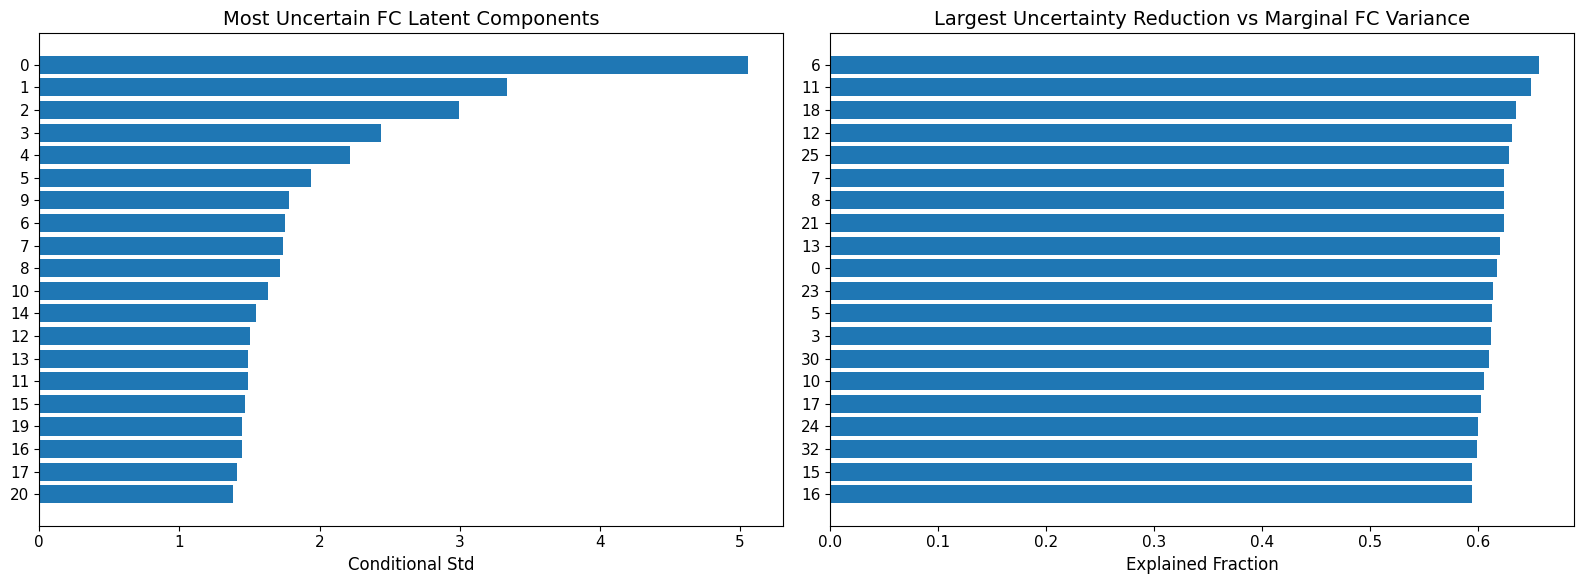

In [17]:
top_n = 20
most_uncertain = uncertainty_df.head(top_n).sort_values("conditional_std")
most_reduced = uncertainty_df.sort_values("explained_fraction", ascending=False).head(top_n).sort_values("explained_fraction")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(most_uncertain["component"].astype(str), most_uncertain["conditional_std"])
axes[0].set_title("Most Uncertain FC Latent Components")
axes[0].set_xlabel("Conditional Std")

axes[1].barh(most_reduced["component"].astype(str), most_reduced["explained_fraction"])
axes[1].set_title("Largest Uncertainty Reduction vs Marginal FC Variance")
axes[1].set_xlabel("Explained Fraction")

plt.tight_layout()
plt.show()

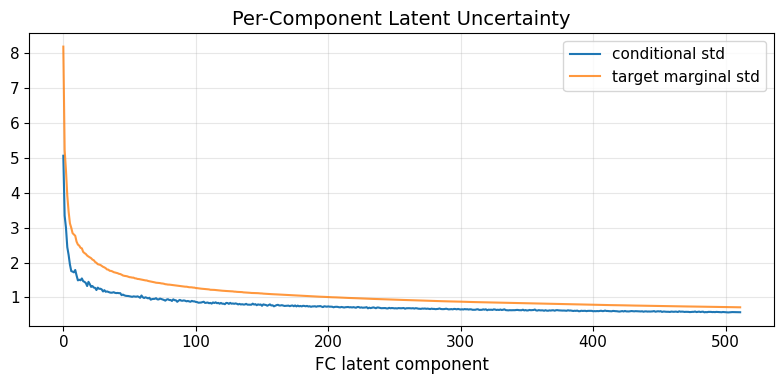

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(conditional_std, label="conditional std")
ax.plot(target_marginal_std, label="target marginal std", alpha=0.8)
ax.set_title("Per-Component Latent Uncertainty")
ax.set_xlabel("FC latent component")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Optional: inspect train latent score covariance directly in the fit space
Z_sc = _to_np(diag["source_pca_scores_train_fit"])
Z_fc = _to_np(diag["target_pca_scores_train_fit"])
print("Z_sc shape:", Z_sc.shape)
print("Z_fc shape:", Z_fc.shape)
print("Average conditional std:", float(conditional_std.mean()))
print("Average uncertainty ratio:", float(uncertainty_ratio.mean()))

Z_sc shape: (683, 711)
Z_fc shape: (683, 512)
Average conditional std: 0.7848588228225708
Average uncertainty ratio: 0.7332686185836792
